In [5]:
import sys
 
import tensorflow as tf
import numpy as np
print(f"Tensor Flow Version: {tf.__version__}")
print(f"Keras Version: {tf.keras.__version__}")
print()
print(f"Python {sys.version}")
gpu = len(tf.config.list_physical_devices('GPU'))>0
print(tf.config.list_physical_devices('GPU'))
print("GPU is", "available"  if gpu else "NOT AVAILABLE")

Tensor Flow Version: 2.11.0
Keras Version: 2.11.0

Python 3.9.13 | packaged by conda-forge | (main, May 27 2022, 17:01:00) 
[Clang 13.0.1 ]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available


In [27]:
taxonomic_classification = ["02957_Animalia_Chordata_Amphibia_Anura_Bufonidae_Bufotes_viridis","02983_Animalia_Chordata_Amphibia_Anura_Hylidae_Hyla_arborea","02992_Animalia_Chordata_Amphibia_Anura_Hylidae_Hyla_meridionalis","03038_Animalia_Chordata_Amphibia_Anura_Ranidae_Pelophylax_ridibundus","03045_Animalia_Chordata_Amphibia_Anura_Ranidae_Rana_italica","03048_Animalia_Chordata_Amphibia_Anura_Ranidae_Rana_temporaria","03097_Animalia_Chordata_Amphibia_Caudata_Salamandridae_Ichthyosaura_alpestris","03100_Animalia_Chordata_Amphibia_Caudata_Salamandridae_Salamandra_atra","03101_Animalia_Chordata_Amphibia_Caudata_Salamandridae_Salamandra_lanzai","03102_Animalia_Chordata_Amphibia_Caudata_Salamandridae_Salamandra_salamandra","04620_Animalia_Chordata_Mammalia_Artiodactyla_Bovidae_Bos_taurus","04623_Animalia_Chordata_Mammalia_Artiodactyla_Bovidae_Capra_hircus","04624_Animalia_Chordata_Mammalia_Artiodactyla_Bovidae_Capra_ibex","04634_Animalia_Chordata_Mammalia_Artiodactyla_Bovidae_Ovis_aries","04637_Animalia_Chordata_Mammalia_Artiodactyla_Bovidae_Rupicapra_rupicapra","04648_Animalia_Chordata_Mammalia_Artiodactyla_Cervidae_Capreolus_capreolus","04650_Animalia_Chordata_Mammalia_Artiodactyla_Cervidae_Cervus_elaphus","04652_Animalia_Chordata_Mammalia_Artiodactyla_Cervidae_Dama_dama","04666_Animalia_Chordata_Mammalia_Artiodactyla_Suidae_Sus_scrofa","04669_Animalia_Chordata_Mammalia_Carnivora_Canidae_Canis_familiaris","04671_Animalia_Chordata_Mammalia_Carnivora_Canidae_Canis_lupus","04677_Animalia_Chordata_Mammalia_Carnivora_Canidae_Vulpes_vulpes","04679_Animalia_Chordata_Mammalia_Carnivora_Felidae_Felis_catus","04696_Animalia_Chordata_Mammalia_Carnivora_Mustelidae_Martes_foina","04697_Animalia_Chordata_Mammalia_Carnivora_Mustelidae_Meles_meles","04700_Animalia_Chordata_Mammalia_Carnivora_Mustelidae_Mustela_nivalis","04719_Animalia_Chordata_Mammalia_Carnivora_Procyonidae_Procyon_lotor","04721_Animalia_Chordata_Mammalia_Carnivora_Ursidae_Ursus_arctos","04745_Animalia_Chordata_Mammalia_Eulipotyphla_Erinaceidae_Erinaceus_europaeus","04751_Animalia_Chordata_Mammalia_Eulipotyphla_Talpidae_Talpa_europaea","04755_Animalia_Chordata_Mammalia_Lagomorpha_Leporidae_Lepus_europaeus","04757_Animalia_Chordata_Mammalia_Lagomorpha_Leporidae_Oryctolagus_cuniculus","04768_Animalia_Chordata_Mammalia_Perissodactyla_Equidae_Equus_asinus","04769_Animalia_Chordata_Mammalia_Perissodactyla_Equidae_Equus_caballus","04801_Animalia_Chordata_Mammalia_Rodentia_Cricetidae_Myodes_glareolus","04803_Animalia_Chordata_Mammalia_Rodentia_Cricetidae_Ondatra_zibethicus","04808_Animalia_Chordata_Mammalia_Rodentia_Echimyidae_Myocastor_coypus","04812_Animalia_Chordata_Mammalia_Rodentia_Hystricidae_Hystrix_cristata","04813_Animalia_Chordata_Mammalia_Rodentia_Muridae_Mus_musculus","04815_Animalia_Chordata_Mammalia_Rodentia_Muridae_Rattus_rattus","04832_Animalia_Chordata_Mammalia_Rodentia_Sciuridae_Marmota_marmota","04849_Animalia_Chordata_Mammalia_Rodentia_Sciuridae_Sciurus_vulgaris","04934_Animalia_Chordata_Reptilia_Squamata_Colubridae_Natrix_natrix","04948_Animalia_Chordata_Reptilia_Squamata_Colubridae_Pantherophis_guttatus","05007_Animalia_Chordata_Reptilia_Squamata_Gekkonidae_Hemidactylus_turcicus","05020_Animalia_Chordata_Reptilia_Squamata_Lacertidae_Lacerta_viridis","05128_Animalia_Chordata_Reptilia_Squamata_Viperidae_Vipera_aspis","05140_Animalia_Chordata_Reptilia_Testudines_Emydidae_Emys_orbicularis","05155_Animalia_Chordata_Reptilia_Testudines_Geoemydidae_Mauremys_leprosa", "05169_Animalia_Chordata_Reptilia_Testudines_Testudinidae_Testudo_hermanni"]
english_animal_names = ["European Green Toad", "European Tree Frog", "Mediterranean Tree Frog", "Marsh Frog", "Italian Stream Frog", "Common Frog", "Alpine Newt", "Alpine Salamander", "Lanza's Salamander", "Fire Salamander", "Domestic Cattle", "Domestic Goat", "Alpine Ibex", "Domestic Sheep", "Chamois", "Roe Deer", "Red Deer", "Fallow Deer", "Wild Boar", "Domestic Dog", "Gray Wolf", "Red Fox", "Domestic Cat", "Beech Marten", "European Badger", "Least Weasel", "Raccoon", "Brown Bear", "European Hedgehog", "European Mole", "European Hare", "European Rabbit", "Donkey", "Horse", "Bank Vole", "Muskrat", "Coypu", "Crested Porcupine", "House Mouse", "Black Rat", "Alpine Marmot", "Red Squirrel", "Grass Snake", "Corn Snake", "Mediterranean House Gecko", "Green Lizard", "Asp Viper", "European Pond Turtle", "Spanish Pond Turtle", "Hermann's Tortoise"]
french_animal_names = ["Crapaud vert", "Rainette verte", "Rainette méridionale", "Grenouille rieuse", "Grenouille italienne", "Grenouille rousse", "Triton alpestre", "Salamandre noire", "Salamandre de Lanza", "Salamandre tachetée", "Bovin domestique", "Chèvre domestique", "Bouquetin des Alpes", "Mouton domestique", "Chamois", "Chevreuil", "Cerf élaphe", "Daim", "Sanglier", "Chien domestique", "Loup gris", "Renard roux", "Chat domestique", "Martre des pins", "Blaireau européen", "Belette", "Raton laveur", "Ours brun", "Hérisson commun", "Taupe européenne", "Lièvre d'Europe", "Lapin de garenne", "Âne", "Cheval", "Campagnol roussâtre", "Rat musqué", "Ragondin", "Porc-épic de Crête", "Souris domestique", "Rat noir", "Marmotte des Alpes", "Écureuil roux", "Couleuvre à collier", "Serpent des blés", "Gecko des maisons", "Lézard vert", "Vipère aspic", "Cistude d'Europe", "Tortue lépreuse", "Tortue d'Hermann"]

2023-04-20 11:34:27.211160: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 1s 1s/step
label 04677_Animalia_Chordata_Mammalia_Carnivora_Canidae_Vulpes_vulpes
preds
[[3.7821525e-04 1.0807167e-03 6.0235645e-04 9.7061339e-04 1.0748835e-03
  5.2409573e-04 5.3679914e-04 4.9541239e-04 9.7049910e-05 1.6109913e-03
  5.9804117e-04 2.0326932e-03 1.8691758e-03 3.8142181e-03 7.5104013e-03
  8.9316786e-04 1.4902658e-03 1.1428091e-03 3.1984062e-03 3.0110485e-03
  5.0256266e-03 9.2556691e-01 1.9509306e-03 6.9206213e-03 2.7977990e-03
  1.8443157e-03 4.0543424e-03 1.2387430e-03 7.5822347e-04 1.0617363e-04
  1.2851196e-03 4.4022943e-04 1.6522205e-03 2.9418026e-03 5.1946676e-04
  1.0251163e-03 4.6413142e-04 5.7686015e-04 4.1148599e-04 2.8675658e-04
  1.0019762e-03 1.9531123e-03 7.0991926e-04 6.6257536e-04 2.6631993e-04
  5.4731063e-04 4.3377295e-04 9.0018602e-04 5.3800101e-04 1.8855071e-04]]
Predicted class: 21
en: Red Fox
fr: Renard roux
, probability:  0.9255669


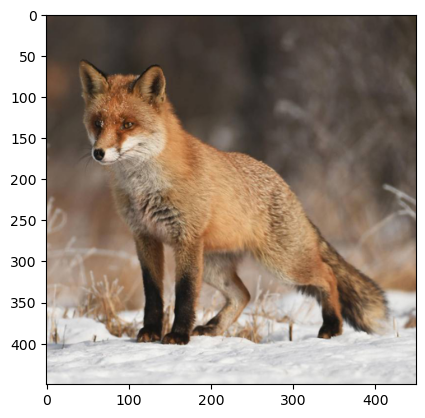

In [32]:
# # TEST MODEL

import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request

# Load the model
model = tf.keras.models.load_model('model.h5')
# img = Image.open('./animals3/test/03103_Animalia_Chordata_Amphibia_Caudata_Salamandridae_Salamandrina_perspicillata/cb480304-c1f1-47f9-9b64-46e677780f25.jpg')
# img = Image.open('./data/animals/test/04620_Animalia_Chordata_Mammalia_Artiodactyla_Bovidae_Bos_taurus/b574441f-e1bd-43da-86f8-8b469b44f1f3.jpg')
img = Image.open('./pre-trained/images/renard.jpeg')
# urllib.request.urlretrieve("https://cdn.branchcms.com/gaenDO8Jz4-1397/images/blog/a-little-house-mouse-on-the-floor.jpg", "file_name")
# img = Image.open(r"file_name")



img = img.resize((450, 450))  # resize to the input size of the model
plt.imshow(img)
img_array = np.array(img) / 255.0  # normalize pixel values to [0, 1]
img_array = np.expand_dims(img_array, axis=0)  # add a batch dimension
preds = model.predict(img_array)
index = np.argmax(preds)
label = taxonomic_classification[index]
print("label", label)
class_idx = np.argmax(preds)
print("preds")
print(preds)
class_prob = preds[0][class_idx]
print("Predicted class:", class_idx)
print("en:", english_animal_names[index])
print("fr:", french_animal_names[index])
print(", probability: ", class_prob)

In [34]:
import urllib.request
from PIL import Image
from io import BytesIO

with urllib.request.urlopen("https://cdn.branchcms.com/gaenDO8Jz4-1397/images/blog/a-little-house-mouse-on-the-floor.jpg") as response:
    # Read the image data from the response
    image_data = response.read()

    # Open the image using Pillow and BytesIO
    img = Image.open(BytesIO(image_data))

img.show()

In [3]:
import os
from keras.models import Model
# from keras.optimizers import Adam
from tensorflow.keras.optimizers import Adam
from keras.applications.vgg16 import VGG16, preprocess_input
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.layers import Dense, Dropout, Flatten
from pathlib import Path
import numpy as np

2023-04-17 23:44:16.319137: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-17 23:44:17.425506: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


(500, 375, 3)

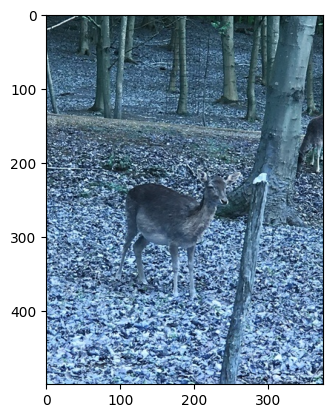

In [4]:
import matplotlib.pyplot as plt
import cv2
image = cv2.imread("./animals3/train/04652_Animalia_Chordata_Mammalia_Artiodactyla_Cervidae_Dama_dama/0bd1adf4-e305-44de-acdc-7f6b6fa677c7.jpg")
plt.imshow(image)
image.shape

In [5]:
BATCH_SIZE = 64

train_generator = ImageDataGenerator(rotation_range=90,
                                     brightness_range=[0.1, 0.7],
                                     width_shift_range=0.5, 
                                     height_shift_range=0.5,
                                     horizontal_flip=True, 
                                     vertical_flip=True,
                                     validation_split=0.15,
                                     preprocessing_function=preprocess_input) # VGG16 preprocessing

test_generator = ImageDataGenerator(preprocessing_function=preprocess_input) # VGG16 preprocessing

In [6]:
download_dir = Path("./animals/")

In [7]:
train_data_dir = download_dir/'train'
test_data_dir = download_dir/'test'


traingen = train_generator.flow_from_directory(train_data_dir,
                                               target_size=(299, 299),
                                               class_mode='categorical',
                                               subset='training',
                                               batch_size=BATCH_SIZE, 
                                               shuffle=True,
                                               seed=42)

validgen = train_generator.flow_from_directory(train_data_dir,
                                               target_size=(299, 299),
                                               class_mode='categorical',
                                               subset='validation',
                                               batch_size=BATCH_SIZE,
                                               shuffle=True,
                                               seed=42)

testgen = test_generator.flow_from_directory(test_data_dir,
                                             target_size=(299, 299),
                                             class_mode=None,
                                             batch_size=1,
                                             shuffle=False,
                                             seed=42)

Found 12166 images belonging to 50 classes.
Found 2142 images belonging to 50 classes.
Found 500 images belonging to 50 classes.


In [8]:
def create_model(input_shape, n_classes, optimizer='rmsprop', fine_tune=0):
    """
    Compiles a model integrated with VGG16 pretrained layers
    
    input_shape: tuple - the shape of input images (width, height, channels)
    n_classes: int - number of classes for the output layer
    optimizer: string - instantiated optimizer to use for training. Defaults to 'RMSProp'
    fine_tune: int - The number of pre-trained layers to unfreeze.
                If set to 0, all pretrained layers will freeze during training
    """
    
    # Pretrained convolutional layers are loaded using the Imagenet weights.
    # Include_top is set to False, in order to exclude the model's fully-connected layers.
    conv_base = VGG16(include_top=False,
                     weights='imagenet', 
                     input_shape=input_shape)
    
    # Defines how many layers to freeze during training.
    # Layers in the convolutional base are switched from trainable to non-trainable
    # depending on the size of the fine-tuning parameter.
    if fine_tune > 0:
        for layer in conv_base.layers[:-fine_tune]:
            layer.trainable = False
    else:
        for layer in conv_base.layers:
            layer.trainable = False

    # Create a new 'top' of the model (i.e. fully-connected layers).
    # This is 'bootstrapping' a new top_model onto the pretrained layers.
    top_model = conv_base.output
    top_model = Flatten(name="flatten")(top_model)
    top_model = Dense(4096, activation='relu')(top_model)
    top_model = Dense(1072, activation='relu')(top_model)
    top_model = Dropout(0.2)(top_model)
    output_layer = Dense(n_classes, activation='softmax')(top_model)
    
    # Group the convolutional base and new fully-connected layers into a Model object.
    model = Model(inputs=conv_base.input, outputs=output_layer)

    # Compiles the model for training.
    model.compile(optimizer=optimizer, 
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [9]:
input_shape = (299, 299, 3)
optim_1 = Adam(learning_rate=0.001)
n_classes=50

n_steps = traingen.samples // BATCH_SIZE
n_val_steps = validgen.samples // BATCH_SIZE
n_epochs = 60

# First we'll train the model without Fine-tuning
vgg_model = create_model(input_shape, n_classes, optim_1, fine_tune=0)

2023-04-17 23:44:22.743743: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:08:00.0/numa_node
Your kernel may have been built without NUMA support.
2023-04-17 23:44:22.903069: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:08:00.0/numa_node
Your kernel may have been built without NUMA support.
2023-04-17 23:44:22.903334: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:08:00.0/numa_node
Your kernel may have been built without NUMA support.
2023-04-17 23:44:22.907614: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:08:00.0/numa_node
Your kernel may have been built without NUMA support.
2023-04-17 23:44:22.908070: I tensorflow/compile

In [10]:
from livelossplot.inputs.keras import PlotLossesCallback

plot_loss_1 = PlotLossesCallback()

# ModelCheckpoint callback - save best weights
tl_checkpoint_1 = ModelCheckpoint(filepath='tl_model_v1.weights.best.hdf5',
                                  save_best_only=True,
                                  verbose=1)

# EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',
                           patience=10,
                           restore_best_weights=True,
                           mode='min')

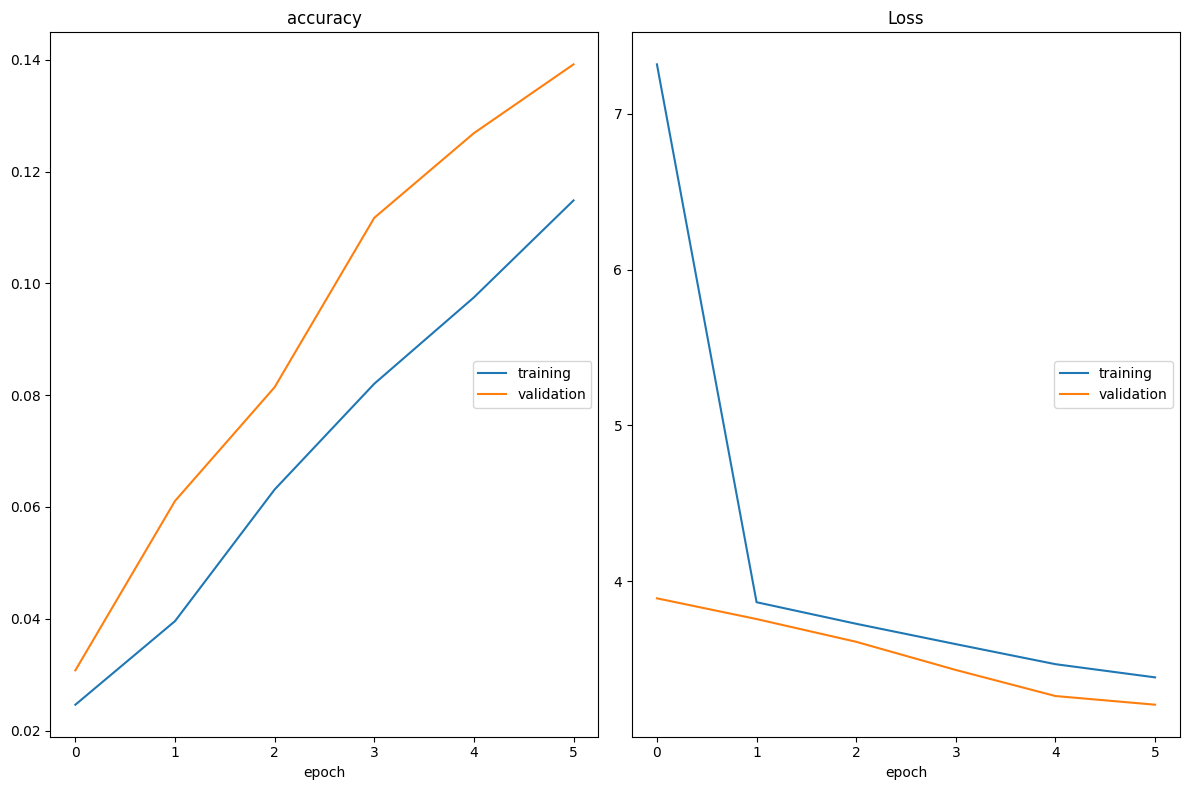

accuracy
	training         	 (min:    0.025, max:    0.115, cur:    0.115)
	validation       	 (min:    0.031, max:    0.139, cur:    0.139)
Loss
	training         	 (min:    3.383, max:    7.318, cur:    3.383)
	validation       	 (min:    3.208, max:    3.891, cur:    3.208)
190/190 [==============================] - 300s 2s/step - loss: 3.3831 - accuracy: 0.1149 - val_loss: 3.2078 - val_accuracy: 0.1392
Epoch 7/60
  8/190 [>.............................] - ETA: 4:01 - loss: 3.2737 - accuracy: 0.1133

KeyboardInterrupt: 

In [11]:
%%time 

vgg_history = vgg_model.fit(traingen,
                            batch_size=BATCH_SIZE,
                            epochs=n_epochs,
                            validation_data=validgen,
                            steps_per_epoch=n_steps,
                            validation_steps=n_val_steps,
                            callbacks=[tl_checkpoint_1, early_stop, plot_loss_1],
                            verbose=1)

In [ ]:
# Generate predictions
vgg_model.load_weights('tl_model_v1.weights.best.hdf5') # initialize the best trained weights

true_classes = testgen.classes
class_indices = traingen.class_indices
class_indices = dict((v,k) for k,v in class_indices.items())

vgg_preds = vgg_model.predict(testgen)
vgg_pred_classes = np.argmax(vgg_preds, axis=1)

In [ ]:
from sklearn.metrics import accuracy_score

vgg_acc = accuracy_score(true_classes, vgg_pred_classes)
print("VGG16 Model Accuracy without Fine-Tuning: {:.2f}%".format(vgg_acc * 100))